# Load the dataset

In [1]:
import os
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import anndata as ad
import scanpy as sc

In [2]:

os.chdir('c:\\Users\\31904\\Desktop\\eTFAST\\')
data_dir = './data/4_human_melanoma_slide_tags/ST/'
# 1. 读取表达矩阵（行是基因，列是细胞）
expr = pd.read_csv(data_dir + 'HumanMelanomaRNA_expression.csv.gz', index_col=0)

# 2. 转置为细胞 × 基因（Scanpy 要求）
expr = expr.T

# 3. 读取元数据和空间坐标
meta = pd.read_csv(data_dir + 'HumanMelanomaRNA_metadata.csv', index_col=0,skiprows=[1])
spatial = pd.read_csv(data_dir + 'HumanMelanomaRNA_spatial.csv', index_col=0, skiprows=[1])

# 4. 创建 AnnData 对象
adata = sc.AnnData(X=expr.values, obs=meta, var=pd.DataFrame(index=expr.columns))

# 5. 添加空间坐标
adata.obsm['spatial'] = spatial[['X', 'Y']].values

print(adata)

AnnData object with n_obs × n_vars = 4804 × 25066
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster'
    obsm: 'spatial'


C:\Users\31904\AppData\Local\Temp\ipykernel_27268\2931940901.py:14: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X=expr.values, obs=meta, var=pd.DataFrame(index=expr.columns))


In [3]:
adata.obs['cell_type'] = adata.obs['cluster'].astype('category')
adata.obs['cell_type'].value_counts()
#把细胞名中的空格替换为下划线
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace('_', ' ')


In [4]:
adata.obs

,biosample_id,donor_id,species,species__ontology_label,disease,disease__ontology_label,organ,organ__ontology_label,library_preparation_protocol,library_preparation_protocol__ontology_label,sex,cluster,cell_type
NAME,,,,,,,,,,,,,
AAACCCACAACTGGTT-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD8_T,CD8 T
AAACCCACATCTCCCA-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,tumour_1,tumour 1
AAACCCACATGCAGCC-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,T_reg,T reg
AAACCCAGTCTTACTT-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD8_T,CD8 T
AAACCCATCACCTTGC-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD4_T,CD4 T
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGACCAGCA-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD8_T,CD8 T
TTTGTTGAGAGTCTGG-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD8_T,CD8 T
TTTGTTGCATAGGAGC-1,melanoma_rna,human_melanoma1,NCBITaxon_9606,Homo sapiens,MONDO:0005105,melanoma,UBERON:0000029,lymph node,EFO_0009922,10x 3' v3,unknown,CD8_T,CD8 T


d:\app\anaconda\envs\tf_env\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Text(0.5, 1.0, 'cell type')

<Figure size 1200x1000 with 0 Axes>

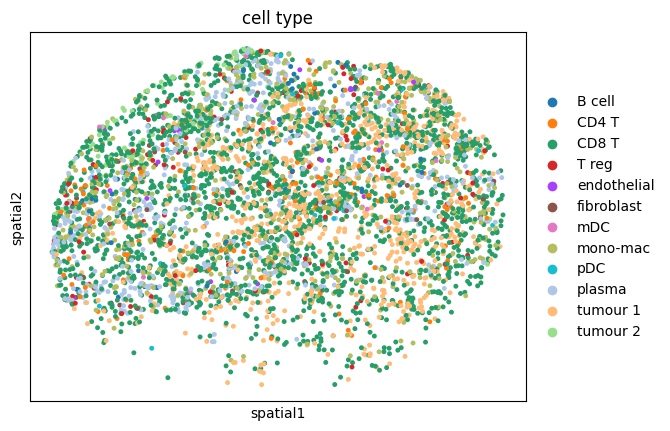

In [5]:
#设置长宽为10，8，图的标题叫celltype
plt.figure(figsize=(12, 10))
sc.pl.embedding(adata, basis="spatial", color=['cell_type'],size=50,legend_loc="right margin",title='cell type', show=False)
plt.title('cell type')

# QC

d:\app\anaconda\envs\tf_env\lib\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


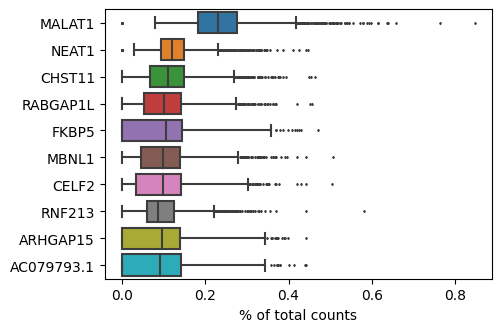

Filtered cell type counts:
cell_type
CD8 T          2119
tumour 1        812
mono-mac        692
plasma          602
CD4 T           198
T reg           123
tumour 2         87
B cell           52
fibroblast       50
pDC              26
mDC              25
endothelial      18
Name: count, dtype: int64


In [6]:
# 计算线粒体基因比例
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 过滤低质量细胞
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 过滤低表达基因
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 显示表达量最高的10个基因
sc.pl.highest_expr_genes(adata, n_top=10)

# 保存原始计数
adata.layers["counts"] = adata.X.copy()

# 标准化
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# 显示过滤后的细胞类型分布
print("Filtered cell type counts:")
print(adata.obs['cell_type'].value_counts())



In [7]:
print(adata.obs['donor_id'].value_counts())

donor_id
human_melanoma1    4804
Name: count, dtype: int64


d:\app\anaconda\envs\tf_env\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Figure size 1200x1500 with 0 Axes>

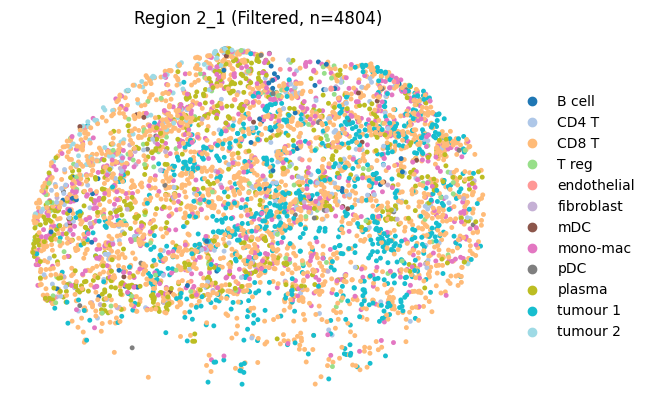

In [8]:


# 绘制空间分布
plt.figure(figsize=(12, 15))
sc.pl.embedding(
    adata,
    basis="spatial",
    color=['cell_type'],
    # palette=filtered_colors,
    size=50,
    title=f"Region 2_1 (Filtered, n={adata.n_obs})",
    legend_loc='right margin',
    frameon=False,
    legend_fontsize=10
)
plt.show()

In [9]:
print(adata.raw)


None


In [10]:
import scipy.sparse
#for BITFAM
exp_matrix = pd.DataFrame(
    adata.X.T.toarray() if scipy.sparse.issparse(adata.X) else adata.X.T,
    index=adata.var_names,  # 基因名
    columns=adata.obs_names  # 细胞名
)
exp_matrix.to_csv('./data/4_human_melanoma_slide_tags/HumanMelanoma_expression_processed.csv')
adata.obs.to_csv('./data/4_human_melanoma_slide_tags/HumanTonsil_expression_metadata.csv')

In [12]:
#for Scenic
import scanpy as sc
ex_matrix = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
ex_matrix.shape
import loompy
loompy.create("data/4_human_melanoma_slide_tags/human_melanoma_processed.loom",
              ex_matrix.T,  # Transpose to match loom convention (genes x cells)
              row_attrs={"Gene": adata.var_names.values},
              col_attrs={"CellID": adata.obs_names.values,})

In [14]:
import requests

url = "https://resources.aertslab.org/cistarget/motif2tf/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"
filename = "motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"

# 下载文件
response = requests.get(url, stream=True)
response.raise_for_status()  # 检查请求是否成功

# 保存文件
with open(filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"文件已下载: {filename}")

KeyboardInterrupt: 

In [20]:
adata.write('./data/4_human_melanoma_slide_tags/human_melanoma_processed.h5ad')
adata


AnnData object with n_obs × n_vars = 4804 × 24877
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_type_colors'
    obsm: 'spatial'
    layers: 'counts'

In [21]:
adata.obs['cell_type'].value_counts()

cell_type
CD8 T          2119
tumour 1        812
mono-mac        692
plasma          602
CD4 T           198
T reg           123
tumour 2         87
B cell           52
fibroblast       50
pDC              26
mDC              25
endothelial      18
Name: count, dtype: int64